#  Generative Adversarial Networks (GAN)
## Introduction

In this tutorial, you will implement a GAN  using PyTorch on MNIST dataset. You will observe its failures and fix it through informed design choices.

## 1. Setup

First, import the required libraries:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else  "mps" if torch.backends.mps.is_available() else "cpu")
print(device)
torch.manual_seed(42)

cuda


## 2. Dataset and DataLoader

We will use the MNIST dataset for training.

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



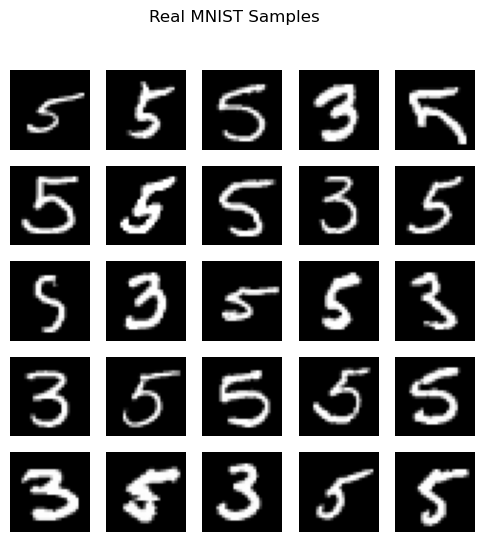

In [2]:


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

indices = (dataset.targets == 5) | (dataset.targets == 3) # if you want to keep images with the label 5
dataset.data, dataset.targets = dataset.data[indices], dataset.targets[indices]

batch_size = 512
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

images, _ = next(iter(loader))

plt.figure(figsize=(6,6))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i][0], cmap="gray")
    plt.axis("off")
plt.suptitle("Real MNIST Samples")
plt.show()


## 3. Define the Generator
The generator takes a random noise vector and generates an image.

📌 Noise input shape: (batch_size, latent_size)

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_size=64, hidden_size=256, image_size=28*28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, image_size),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


## 4. Define the Discriminator
The discriminator classifies images as real or fake.

In [4]:
class Discriminator(nn.Module):

    def __init__(self, hidden_size=256, image_size=28*28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(image_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


## 5. Training loop
The training process involves updating both the generator and discriminator.

In [5]:
def train_gan(epochs, loader, D, G, optimizer_D, optimizer_G, criterion, latent_size=64):
    losses_D = []
    losses_G = []

    for epoch in range(epochs):
        for real, _ in loader:

            batch_size = real.size(0)

            real = real.view(batch_size, -1).to(device)
            
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)
            
            # ---- Train Discriminator ----
            D.zero_grad()

            D_real = D(real)
            errD_real = criterion(D_real, real_labels)

            z = torch.randn(batch_size, latent_size).to(device)
            fake = G(z)
            D_fake = D(fake.detach())
            errD_fake = criterion(D_fake, fake_labels)
       
            loss_D = errD_real + errD_fake
            loss_D.backward()
            optimizer_D.step()

            # ---- Train Generator ----
            G.zero_grad()
            D_fake = D(fake)
            loss_G = criterion(D_fake, real_labels)
            loss_G.backward()
            optimizer_G.step()
        

        losses_D.append(loss_D.item())
        losses_G.append(loss_G.item())
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

    plt.figure(figsize=(10,5))
    plt.title("Generator and Discriminator Loss During Training")
    plt.plot(losses_G,label="G")
    plt.plot(losses_D,label="D")
    plt.xlabel("iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    


## 6. Create and train a GAN

Epoch [1/100] | D Loss: 0.9155 | G Loss: 0.6657
Epoch [2/100] | D Loss: 1.2165 | G Loss: 0.6251
Epoch [3/100] | D Loss: 1.2889 | G Loss: 0.6811
Epoch [4/100] | D Loss: 1.2345 | G Loss: 0.7770
Epoch [5/100] | D Loss: 1.2486 | G Loss: 0.8933
Epoch [6/100] | D Loss: 1.1314 | G Loss: 0.9653
Epoch [7/100] | D Loss: 1.2400 | G Loss: 0.8273
Epoch [8/100] | D Loss: 1.3448 | G Loss: 0.6641
Epoch [9/100] | D Loss: 1.2890 | G Loss: 0.7260
Epoch [10/100] | D Loss: 1.1844 | G Loss: 0.9452
Epoch [11/100] | D Loss: 1.0713 | G Loss: 0.8660
Epoch [12/100] | D Loss: 0.8398 | G Loss: 1.0553
Epoch [13/100] | D Loss: 0.7057 | G Loss: 1.3684
Epoch [14/100] | D Loss: 0.4589 | G Loss: 1.9271
Epoch [15/100] | D Loss: 0.5531 | G Loss: 2.2502
Epoch [16/100] | D Loss: 0.5256 | G Loss: 2.3793
Epoch [17/100] | D Loss: 0.2605 | G Loss: 2.4004
Epoch [18/100] | D Loss: 0.3940 | G Loss: 2.1728
Epoch [19/100] | D Loss: 0.6150 | G Loss: 0.9319
Epoch [20/100] | D Loss: 0.6401 | G Loss: 1.6717
Epoch [21/100] | D Loss: 0.47

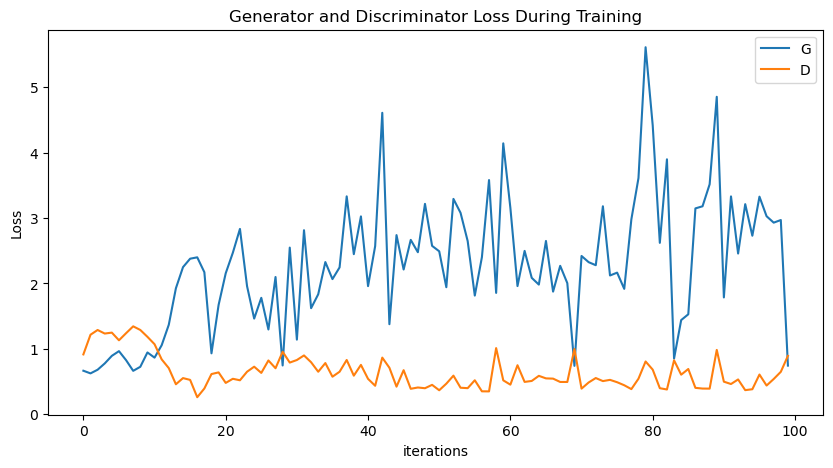

In [6]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 100

train_gan(epochs, loader, D, G, optimizer_D, optimizer_G, criterion)

## 6. Generate and Visualize Fake Images


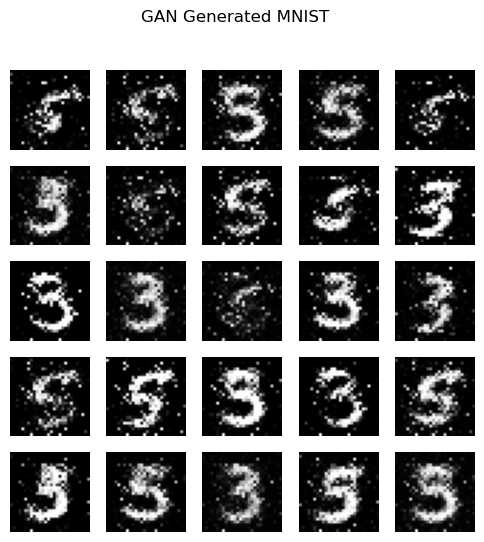

In [7]:
def generate_fakes(G, n = 100, latent_size=64):
    z = torch.randn(n, latent_size).to(device)
    samples = G(z).detach().cpu()
    samples = samples.view(samples.size(0), 1, 28, 28)

    plt.figure(figsize=(6,6))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.imshow(samples[i][0], cmap="gray")
        plt.axis("off")
    plt.suptitle("GAN Generated MNIST")
    plt.show()

generate_fakes(G)

# Exercises
## 1. Latent space
Reduce the size of the latent space and check the results.


In [ ]:
# Write your code here


## 2. Label smoothing
One-sided label smoothing is a training technique, commonly used in GANs, that slightly softens the real labels given to the discriminator, while leaving the fake labels unchanged. In a vanilla GAN, real images are labeled with 1.0 and fake images with 0.0. This encourages the discriminator to become very confident, which can cause vanishing gradients for the generator, training instability or overconfident discriminator decisions.

Smoothing only real labels prevents the discriminator from becoming overconfident, keeps the adversarial game meaningful and preserves strong gradients for the generator.

Modify the training function to replace the 1.0 label value of real images with random values uniformly distributed in a range close to 1. Train a new GAN and check the results.

In [ ]:
# Write your code here